In [4]:
#####
# IMPORTANT: before running this script, you need to use the 'subset_species_tables.py' script that generates
# single-species specific subsets of all of the larger, global files
#####

# This case study is based on species 2269_1
# Therefore, first run the 'subset_species_tables.py' by providing that species identifier
# Then provide the output directory path that you specified to that script as the 'input_dir_case_study' variable below 

# Load libraries and set variables

In [ ]:
#####
# Load libraries
#####
suppressPackageStartupMessages(library("vegan"))
suppressPackageStartupMessages(library("reshape2"))
suppressPackageStartupMessages(library("patchwork"))
suppressPackageStartupMessages(library("tidyverse"))
suppressPackageStartupMessages(library("data.table"))
suppressPackageStartupMessages(library("maps"))
suppressPackageStartupMessages(library("KEGGREST"))


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
#####
# Define variables
#####
species_id="2269_1"
input_dir=c('XXXXX') ### Directory containing main tables from the Zenodo repository
input_dir_case_study=c('XXXXX') ### Should be set to the output table provided to the script 'subset_species_tables.py'
output_dir=c('XXXXX') ### Directory to store tables and figures

dir.create(paste0(output_dir))

subsp_colours = c("Subspecies_0" = "#004949", "Subspecies_1" = "#ffb6db", "Subspecies_2" = "#9467bd")
gene_level_cols = c("Universal" = "#4d4d4d", "Shared" = "#999999", "Unique" = "#e6e6e6")

Warning message in dir.create(paste0(output_dir, species_id)):
“'/nfs/nas22/fs2202/biol_micro_sunagawa/Projects/EAN/OMDV2_POPGEN_EAN/scratch/processed/final/case_studies/2269_1' already exists”


# Import tables

In [5]:
#####
# Import data
#####
### Sample metadata
sample_meta = fread(paste0(input_dir,"Samples_metadata.tsv"), sep = "\t", dec = ",", header=T)

### Species' samples SNV distances
sp_samp_snv_dist = fread(paste0(input_dir_case_study,species_id,".snv_distances.tsv"), sep = "\t", header=T) %>%
    mutate(
        Subspecies_one = paste0("Subspecies_",cluster_1),
        Subspecies_two = paste0("Subspecies_",cluster_2),
        Category = case_when(
            comp == "Same population" ~ "Same subspecies",
            comp == "Different populations" ~ "Different subspecies")
    ) %>%
    rename(
        Species = species,
        Sample_one = sample_1,
        Sample_two = sample_2,
        SNV_distance = dist) %>%
    select(-c(refg,cluster_1,cluster_2,comp))

### Species to sample to subspecies mapping
sp_to_samp_to_subsp = fread(paste0(input_dir_case_study,species_id,".species_to_sample.tsv"), sep = "\t", header=T) 

### Species gene catalog profile
sp_gene_catalog = fread(paste0(input_dir_case_study,species_id,".gene_catalog_profile.tsv"), sep = "\t", header=T) 

### Species gene and function content
species_gene_comp = fread(file=paste0(input_dir_case_study,species_id,".species_gene_composition.tsv"), sep="\t", header=T) 

species_core_genes = fread(file=paste0(input_dir_case_study,species_id,".subspecies_core_genes.tsv"), sep="\t", header=T) 

species_core_pfam = fread(file=paste0(input_dir_case_study,species_id,".subspecies_core_pfam.tsv"), sep="\t", header=T)

species_core_kegg = fread(file=paste0(input_dir_case_study,species_id,".subspecies_core_kegg.tsv"), sep="\t", header=T) 

### Sample UMAP embeddings
sp_umap_embed = fread(paste0(input_dir,"SUBSPECIES-EMBEDDINGS.tsv"), sep = "\t", header=T) %>%
    filter(., Species == species_id) %>%
    left_join(sp_to_samp_to_subsp, by=c("Species","Sample"))

### Species gene pNpS values - and filter to only retain population core genes
species_pnps = fread(paste0(input_dir_case_study,species_id,".pnps_per_gene_sample.tsv"), sep = "\t", header=T) %>%
    filter(., gene_catalog_representative %in% species_core_genes$Gene_catalog_rep) %>%
    rename(Gene_catalog_rep = gene_catalog_representative, pNpS = pNpS_gene_reference, Sample = sample)

# SNV distance UMAP

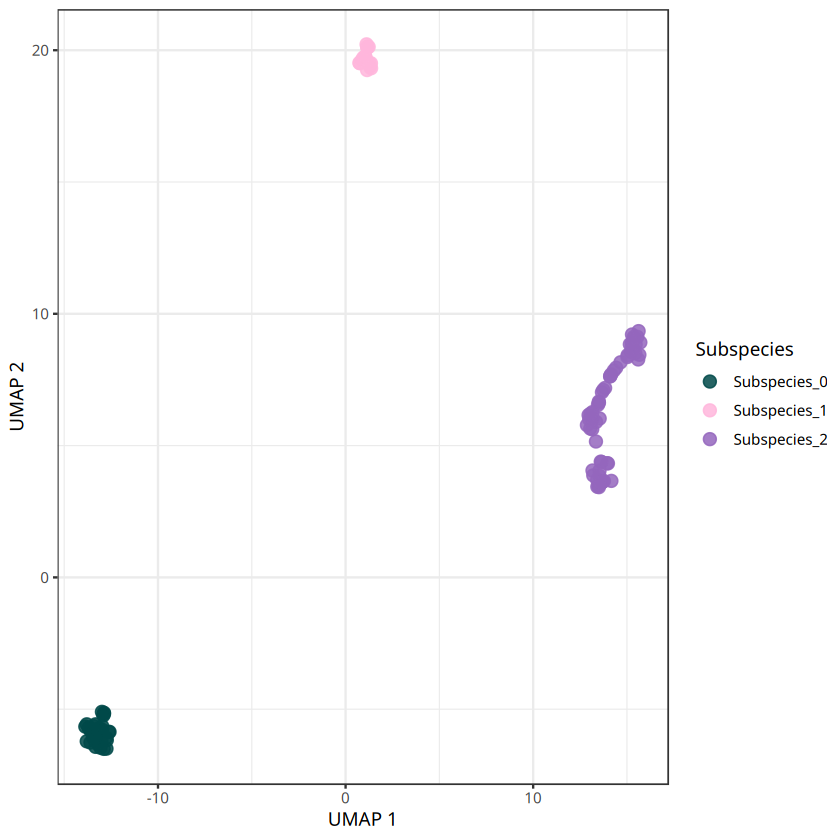

In [31]:
### Visualise UMAP
subsp_sample_snv_dist_umap  = 
  ggplot(sp_umap_embed, aes(x = V1, y = V2, colour = Subspecies)) +
  geom_point(size = 3, alpha = 0.85) +
  scale_colour_manual(values = subsp_colours) +
  labs(x = "UMAP 1", y = "UMAP 2") +
  theme_bw()

subsp_sample_snv_dist_umap

ggsave(paste0(output_dir,species_id,"-sample_umap.pdf"), plot = subsp_sample_snv_dist_umap, device = "pdf", height = 6, width = 6, units = "in")
ggsave(paste0(output_dir,species_id,"-sample_umap.png"), plot = subsp_sample_snv_dist_umap, device = "png", height = 6, width = 6, units = "in")

# Distribution across oceans and env. gradients

In [32]:
#####
# Visualise distribution of species across oceans and environmental gradients
#####

sp_samples_with_meta = sp_to_samp_to_subsp %>%
    left_join(sample_meta, by = "Sample")

sp_samples_with_meta_map = sp_samples_with_meta %>%
    filter(., !is.na(latitude), !is.na(longitude))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


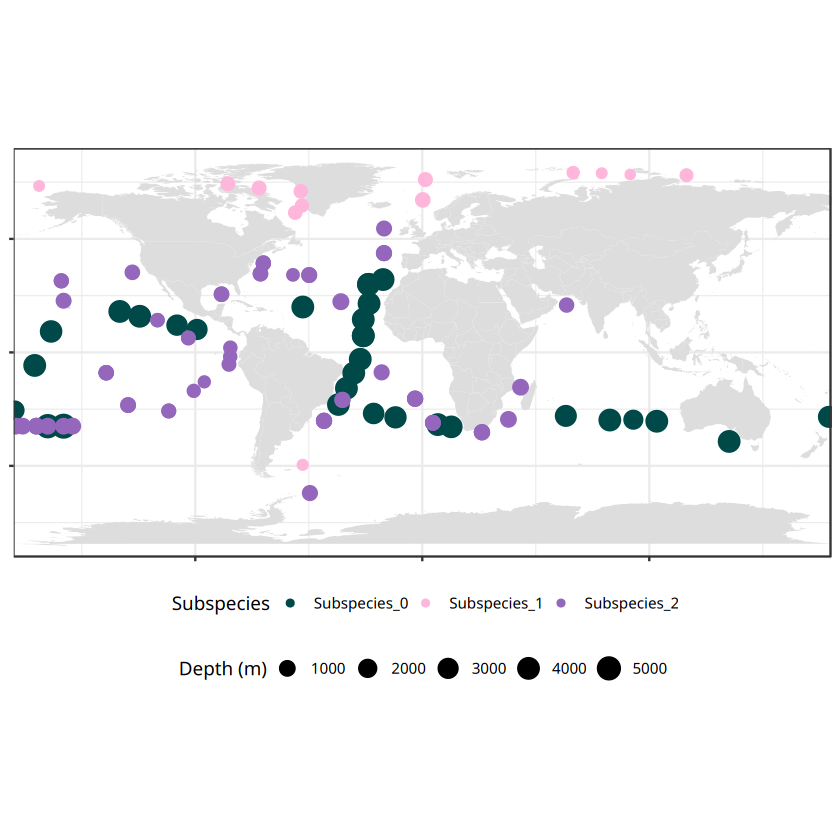

In [33]:
### Visualise distribution across oceans in a map
world_map <- map_data("world")  # plain data frame, no spatial objects

species_map <- ggplot() +
    geom_polygon(data = world_map,
                 aes(x = long, y = lat, group = group),
                 fill = "#dddddd", color = NA) +
    geom_point(data = sp_samples_with_meta_map,
               aes(x = longitude, y = latitude, color = Subspecies, size = as.numeric(depth_num))) +
    scale_colour_manual(values = subsp_colours) +
    scale_size(range = c(2, 6)) +
    coord_quickmap(xlim = c(-180, 180), ylim = c(-90, 90), expand = FALSE) +
    labs(size = "Depth (m)") +
    theme_bw() +
    theme(
    legend.position  = "bottom",
    legend.box = "vertical", 
    # panel.grid = element_blank(),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank())  +
  guides(
    colour = guide_legend(order = 1, nrow = 1), 
    size   = guide_legend(order = 2, nrow = 1)
  )
species_map

ggsave(paste0(output_dir,species_id,"-sample_distribution.pdf"), plot = species_map, device = "pdf", height = 6, width = 8, units = "in")
ggsave(paste0(output_dir,species_id,"-sample_distribution.png"), plot = species_map, device = "png", height = 6, width = 8, units = "in")

Warning message:
“Removed 127 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


Warning message:
“Removed 127 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 127 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


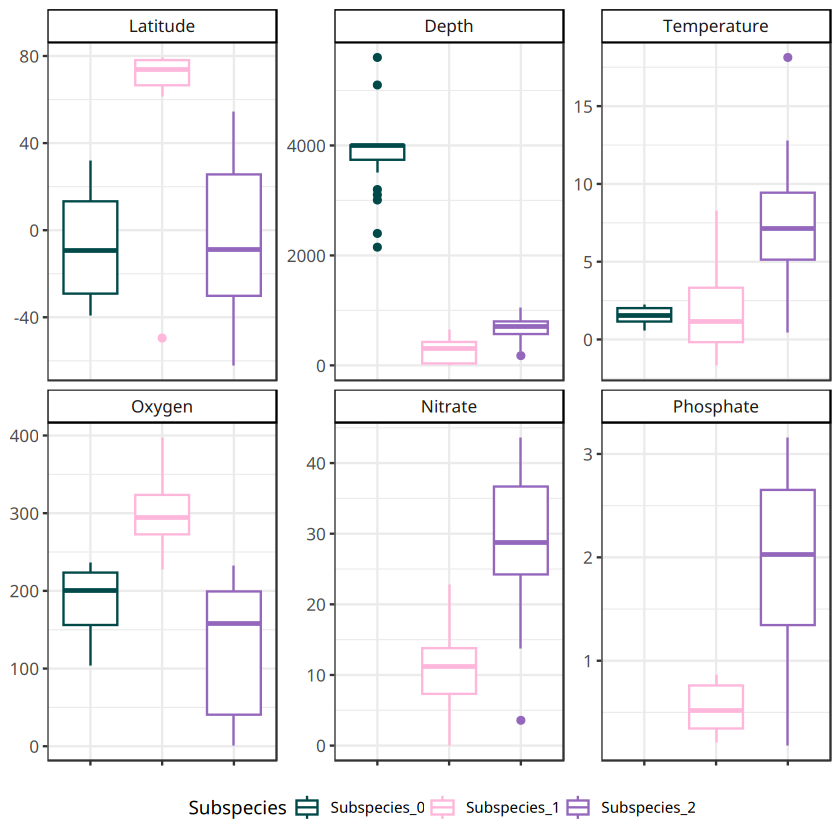

In [34]:
#####

### Assess subspecies distribution across environmental gradients

#####

sp_phased_samples_w_meta_long = sp_samples_with_meta %>%
    select(Sample,Subspecies,Latitude=latitude,Depth=depth_num,Temperature=temperature_situ,Oxygen=oxygen_situ,Nitrate=nitrate_situ,Phosphate=phosphate_situ) %>%
    melt(., id.vars=c("Sample","Subspecies"), variable.name="env_var", value.name="Value") %>%
    filter(Subspecies != "Subspecies") %>%
    # mutate(env_var = str_to_title(env_var)) %>%
    mutate(env_var = factor(env_var, levels=c("Latitude","Depth","Temperature","Oxygen","Nitrate","Phosphate"))) 

sp_phased_samples_env_boxplot = ggplot(sp_phased_samples_w_meta_long, aes(x = Subspecies, y = as.numeric(Value))) + 
    geom_boxplot(aes(colour = Subspecies)) + 
    facet_wrap(~env_var, scales="free_y", nrow=2) + 
    scale_colour_manual(values=subsp_colours) + 
    theme_bw() + 
    theme(legend.position="bottom",
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    axis.text.y = element_text(size = 10),
    strip.background.x = element_rect(fill = "white", colour = "black"),
    strip.text.x = element_text(size = 10))
sp_phased_samples_env_boxplot

ggsave(paste0(output_dir,species_id,"-env_var_boxplot.pdf"), plot = sp_phased_samples_env_boxplot, device = "pdf", height=5, width=6, units = "in")
ggsave(paste0(output_dir,species_id,"-env_var_boxplot.png"), plot = sp_phased_samples_env_boxplot, device = "png", height=5, width=6, units = "in")


# Subspecies gene composition

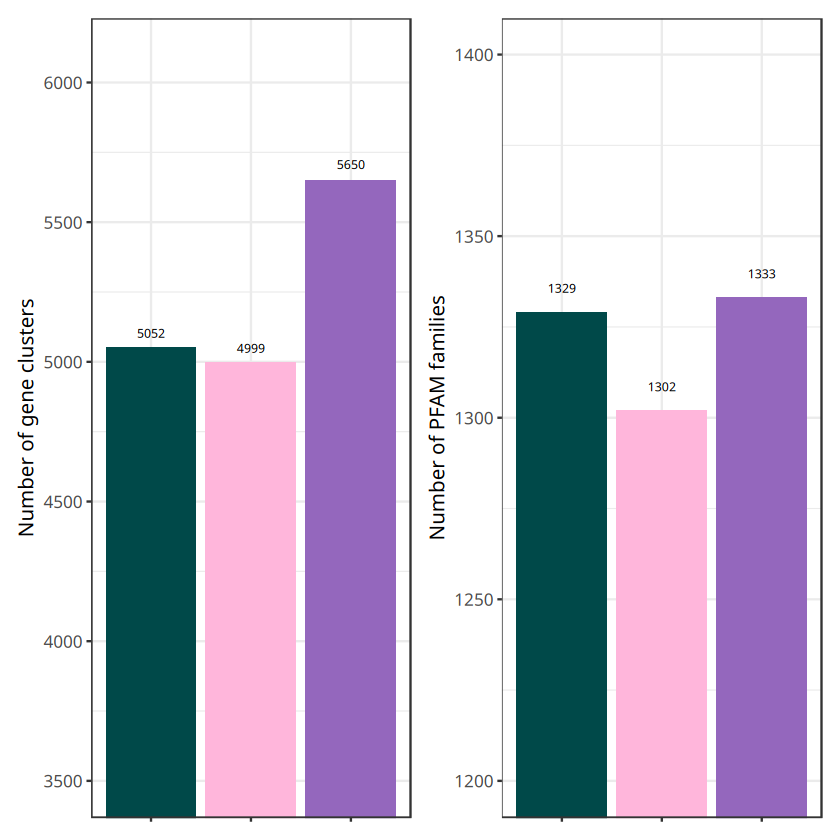

In [35]:
#####
# Extract and visualise differences in the number of gene clusters and PFAMs in the core genome of each subspecies
#####
  
### Gene cluster counts
subspecies_gene_cluster_counts = species_core_genes %>%
    select(Subspecies,Gene_catalog_rep) %>%
    distinct() %>%
    select(Subspecies) %>%
    table() %>%
    as.data.frame()

subspecies_gene_cluster_counts_barplot = ggplot(subspecies_gene_cluster_counts, aes(x=Subspecies, y=Freq)) +
    geom_bar(aes(fill = Subspecies), position="identity", stat="identity") +
    geom_text(aes(x = Subspecies, y = Freq*1.01, label = Freq),
      inherit.aes = FALSE,
      size = 2.5,
      color = "black"
    ) +
    scale_fill_manual(values=subsp_colours) + 
    labs(y = "Number of gene clusters") + 
    coord_cartesian(ylim = c(3500, 6100)) + 
    theme_bw() + 
    theme(legend.position="none",
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_blank(),
    axis.text.x = element_blank())

### PFAM family counts
subspecies_pfam_family_counts = species_core_pfam %>%
    select(Subspecies,PFAM_accession) %>%
    distinct() %>%
    select(Subspecies) %>%
    table() %>%
    as.data.frame()

subspecies_pfam_family_counts_barplot = ggplot(subspecies_pfam_family_counts, aes(x=Subspecies, y=Freq)) +
    geom_bar(aes(fill = Subspecies), position="identity", stat="identity") +
    geom_text(aes(x = Subspecies, y = Freq*1.005, label = Freq),
      inherit.aes = FALSE,
      size = 2.5,
      color = "black"
    ) +
    scale_fill_manual(values=subsp_colours) + 
    labs(y = "Number of PFAM families") + 
    coord_cartesian(ylim = c(1200, 1400)) + 
    theme_bw() + 
    theme(legend.position="none",
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_blank(),
    axis.text.x = element_blank())

subspecies_gene_content_barplot <- subspecies_gene_cluster_counts_barplot+subspecies_pfam_family_counts_barplot
subspecies_gene_content_barplot

ggsave(paste0(output_dir,species_id,"-gene_comp_counts_barplot.pdf"), plot = subspecies_gene_content_barplot, device = "pdf", height=5, width=8, units = "in")
ggsave(paste0(output_dir,species_id,"-gene_comp_counts_barplot.png"), plot = subspecies_gene_content_barplot, device = "png", height=5, width=8, units = "in")

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


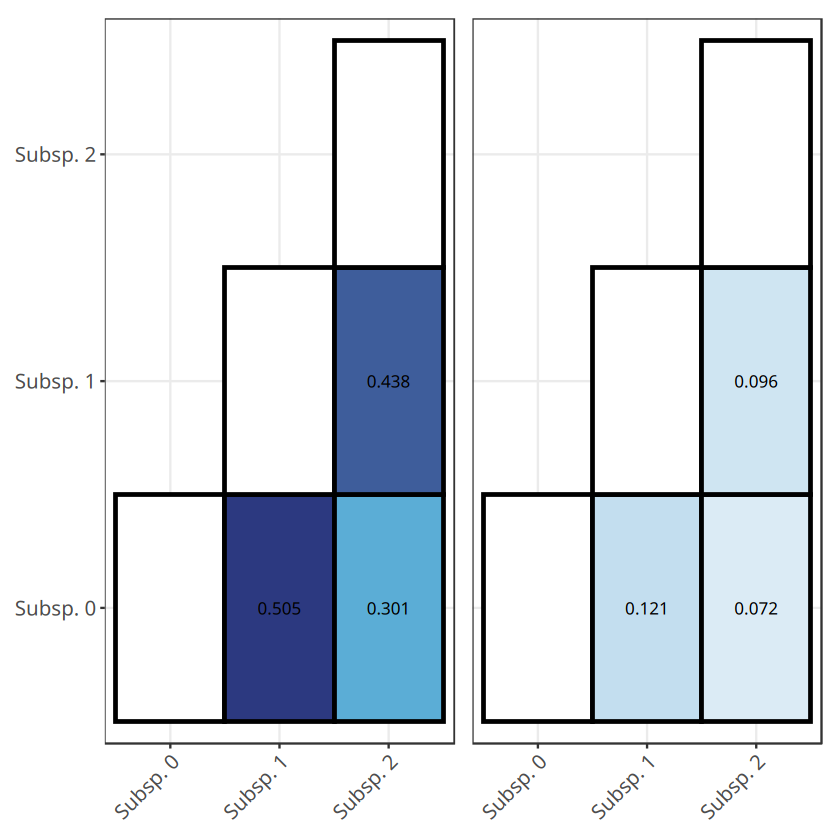

In [36]:
#####
# Visualise jaccard dissimilarities of subspecies gene and pfam content 
#####

### Gene cluster jaccard distances
subspecies_gene_cluster_matrix = species_core_genes %>%
    select(Subspecies, Gene_catalog_rep) %>%
    distinct() %>%
    mutate(value = 1) %>%
    pivot_wider(names_from = Gene_catalog_rep, values_from = value, values_fill = 0) %>%
    column_to_rownames("Subspecies")

mat <- as.matrix(vegdist(subspecies_gene_cluster_matrix, method = "jaccard"))
mat[upper.tri(mat)] <- NA

subspecies_gene_cluster_jaccard <- as.data.frame(mat) %>%
  tibble::rownames_to_column("Subspecies_one") %>%
  reshape2::melt(
    id.vars = "Subspecies_one",
    variable.name = "Subspecies_two",
    value.name = "Jaccard_distance",
    na.rm = TRUE
  ) %>%
  mutate(Jaccard_distance = if_else(Subspecies_one == Subspecies_two, NA_real_, Jaccard_distance))  %>%
  mutate(Subspecies_one = case_when(
    Subspecies_one == "Subspecies_0" ~ "Subsp. 0", 
    Subspecies_one == "Subspecies_1" ~ "Subsp. 1", 
    Subspecies_one == "Subspecies_2" ~ "Subsp. 2"
    ),
  Subspecies_two = case_when(
    Subspecies_two == "Subspecies_0" ~ "Subsp. 0", 
    Subspecies_two == "Subspecies_1" ~ "Subsp. 1", 
    Subspecies_two == "Subspecies_2" ~ "Subsp. 2"
    )   
  )

subspecies_gene_cluster_jaccard_dist_heatmap = 
  ggplot(subspecies_gene_cluster_jaccard, aes(x = Subspecies_one, y = Subspecies_two, fill = Jaccard_distance), show.legend = F) +
  geom_tile(colour = "black", linewidth=1) +
  geom_text(aes(label = round(Jaccard_distance, 3)),
            colour = "black", size = 3.5) +
  scale_fill_gradient2(
    low = "#ffffff",
    mid = "#5BAED6",
    high = "#03045A",
    na.value = "#ffffff",
    midpoint = 0.3,
    limits=c(0,0.55)
  ) +
  theme_bw() + 
  labs(
    fill = "Jaccard\ndistance",
  ) + 
  theme(
  legend.position = "none",
  axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
  axis.text.y = element_text(size = 12),
  axis.title.y = element_blank(),
  axis.title.x = element_blank(),
  legend.text = element_text(size = 10),
  legend.title = element_text(size = 10))


### Pfam family jaccard distances
subspecies_pfam_matrix = species_core_pfam %>%
    select(Subspecies, PFAM_accession) %>%
    distinct() %>%
    mutate(value = 1) %>%
    pivot_wider(names_from = PFAM_accession, values_from = value, values_fill = 0) %>%
    column_to_rownames("Subspecies")

mat <- as.matrix(vegdist(subspecies_pfam_matrix, method = "jaccard"))
mat[upper.tri(mat)] <- NA

subspecies_pfam_jaccard <- as.data.frame(mat) %>%
  tibble::rownames_to_column("Subspecies_one") %>%
  reshape2::melt(
    id.vars = "Subspecies_one",
    variable.name = "Subspecies_two",
    value.name = "Jaccard_distance",
    na.rm = TRUE
  )  %>%
  mutate(Jaccard_distance = if_else(Subspecies_one == Subspecies_two, NA_real_, Jaccard_distance))  %>%
  mutate(Subspecies_one = case_when(
    Subspecies_one == "Subspecies_0" ~ "Subsp. 0", 
    Subspecies_one == "Subspecies_1" ~ "Subsp. 1", 
    Subspecies_one == "Subspecies_2" ~ "Subsp. 2"
    ),
  Subspecies_two = case_when(
    Subspecies_two == "Subspecies_0" ~ "Subsp. 0", 
    Subspecies_two == "Subspecies_1" ~ "Subsp. 1", 
    Subspecies_two == "Subspecies_2" ~ "Subsp. 2"
    )   
  )

subspecies_pfam_jaccard_dist_heatmap = 
  ggplot(subspecies_pfam_jaccard, aes(x = Subspecies_one, y = Subspecies_two, fill = Jaccard_distance), show.legend = F) +
  geom_tile(colour = "black", linewidth=1) +
  geom_text(aes(label = round(Jaccard_distance, 3)),
            colour = "black", size = 3.5) +
  scale_fill_gradient2(
    low = "#ffffff",
    mid = "#5BAED6",
    high = "#03045A",
    na.value = "#ffffff",
    midpoint = 0.3,
    limits=c(0,0.55)
  ) +
  theme_bw() + 
  labs(
    fill = "Jaccard\ndistance",
  ) + 
  theme(
  legend.position = "none",
  axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
  axis.text.y = element_text(size = 12),
  axis.title.y = element_blank(),
  axis.title.x = element_blank(),
  legend.text = element_text(size = 10),
  legend.title = element_text(size = 10))

subspecies_gene_comp_jaccard_heatmap <- subspecies_gene_cluster_jaccard_dist_heatmap+subspecies_pfam_jaccard_dist_heatmap+
  plot_layout(axes = "collect")
subspecies_gene_comp_jaccard_heatmap


ggsave(paste0(output_dir,species_id,"-pop_gene_comp_jacc_dist_heatmap.pdf"), plot = subspecies_gene_comp_jaccard_heatmap, device = "pdf", height=5, width=8, units = "in")
ggsave(paste0(output_dir,species_id,"-pop_gene_comp_jacc_dist_heatmap.png"), plot = subspecies_gene_comp_jaccard_heatmap, device = "png", height=5, width=8, units = "in")

## Extract population-specific KEGG kos and Pfams

In [37]:
#####
# Identifying unique or shared KEGG KO's, i.e. subspecies-specific and not universal in species
#####
num_pops <- length(unique(sp_to_samp_to_subsp$Subspecies))

kegg_ko_to_category = species_core_kegg %>%
    select(Subspecies,KEGG_ko) %>%
    unique() %>%
    group_by(KEGG_ko) %>%
    summarise(
        Count = n_distinct(Subspecies),
        .groups = "drop"
    ) %>%
    mutate(Category = case_when(
        Count < num_pops & Count > 1 ~ "Shared",
        Count == 1 ~ "Unique",
        TRUE ~ "Universal"
    )) %>%
    select(KEGG_ko,Category)

unique_kegg_kos = species_core_kegg %>%
    select(Subspecies,KEGG_ko) %>%
    unique() %>%
    filter(., !is.na(KEGG_ko), KEGG_ko != "-") %>%
    left_join(kegg_ko_to_category, by="KEGG_ko") %>%
    filter(Category == "Unique")

head(unique_kegg_kos, n=2)

# fwrite(unique_kegg_kos, paste0(output_dir,species_id,"-unique_kegg_kos.tsv"), sep = "\t")


Subspecies,KEGG_ko,Category
<chr>,<chr>,<chr>
Subspecies_0,K00936,Unique
Subspecies_0,K01081,Unique


In [38]:
#####
# Identifying unique or shared PFAM families, i.e. population-specific and not universal in species
#####

pfam_to_category = species_core_pfam %>%
    select(Subspecies,PFAM_accession) %>%
    unique() %>%
    group_by(PFAM_accession) %>%
    summarise(
        Count = n_distinct(Subspecies),
        .groups = "drop"
    ) %>%
    mutate(Category = case_when(
        Count < num_pops & Count > 1 ~ "Shared",
        Count == 1 ~ "Unique",
        TRUE ~ "Universal"
    )) %>%
    select(PFAM_accession,Category)

unique_pfam= species_core_pfam %>%
    select(Subspecies,PFAM_accession) %>%
    unique() %>%
    filter(., !is.na(PFAM_accession), PFAM_accession != "-") %>%
    left_join(pfam_to_category, by="PFAM_accession") %>%
    filter(Category == "Unique")

# fwrite(unique_pfam, paste0(output_dir,species_id,"-unique_pfam_families.tsv"), sep = "\t")


# Analyse pNpS

## Filter data

In [6]:
species_gene_to_annot = species_gene_comp %>%
    select(Gene_catalog_rep,KEGG_ko,PFAM_accession) %>%
    unique()

### Filter pNpS to only include:
### 1) species of interest
### 2) samples passing threshold 
### 3) core genes of populations

samp_to_subsp <- sp_to_samp_to_subsp %>%
  select(Sample, Subspecies) %>%
  distinct()

n_total_pops <- length(unique(samp_to_subsp$Subspecies))

sp_genes_pnps_filt <- species_pnps %>%
  filter(Sample %in% samp_to_subsp$Sample) %>%
  filter(Gene_catalog_rep %in% species_core_genes$Gene_catalog_rep) %>%
  select(Sample, Gene_catalog_rep, pNpS) %>%
  distinct() %>%
  left_join(samp_to_subsp, by = "Sample") %>%
  filter(is.finite(pNpS), !is.na(pNpS)) %>%
  distinct()

# Category derived from Subspecies-aware table
core_gene_categories <- sp_genes_pnps_filt %>%
  select(Gene_catalog_rep, Subspecies) %>%
  distinct() %>%
  group_by(Gene_catalog_rep) %>%
  summarise(n_pops = n_distinct(Subspecies), .groups = "drop") %>%
  mutate(Category = case_when(
    n_pops == n_total_pops ~ "Universal",
    n_pops > 1 ~ "Shared",
    TRUE ~ "Unique"
  ))

## Species core gene cluster comparison

In [7]:
# Final table: inner join restricts to CORE genes only,
# then attach category and annotations independently
sp_genes_pnps_filt_w_cat <- sp_genes_pnps_filt %>%
  inner_join(
    core_gene_categories %>% select(Gene_catalog_rep),
    by = "Gene_catalog_rep"
  ) %>%
  left_join(core_gene_categories, by = "Gene_catalog_rep") %>%
  left_join(species_gene_to_annot, by = "Gene_catalog_rep") %>%
  distinct()

## Compare species core genes pNpS across populations

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


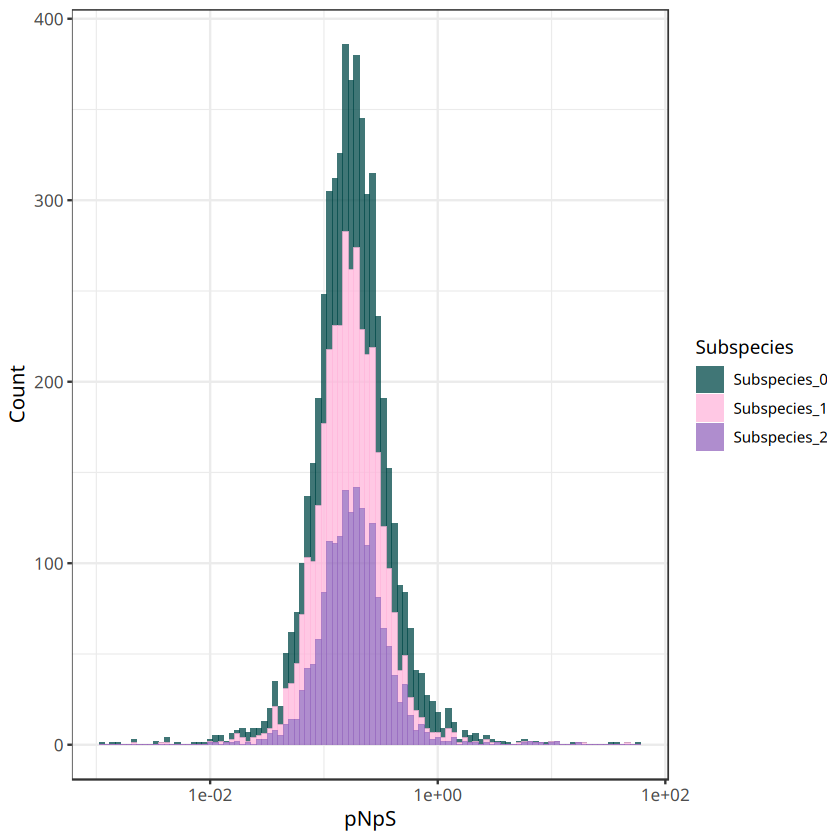

In [8]:
### Visualise pNpS values across species core genes
sp_core_genes_pop_mean_pnps = sp_genes_pnps_filt_w_cat %>%
  filter(., Category == "Universal") %>%
  group_by(Gene_catalog_rep, Subspecies, PFAM_accession) %>%
  summarise(
    pop_mean_pNpS = mean(pNpS, na.rm = TRUE),
    n_samples = n(),
    .groups = "drop"
  )

sp_core_gene_pop_mean_pnps_histogram = ggplot(sp_core_genes_pop_mean_pnps, aes(x = pop_mean_pNpS, fill = Subspecies)) +
  geom_histogram(bins = 100, alpha = 0.75) +
  scale_x_log10() +
  theme_bw() + 
  labs(x = "pNpS",
       y = "Count"
  ) +
  scale_fill_manual(values = subsp_colours) + 
  theme(
    strip.background = element_rect(fill = "white", colour = "black"),
    strip.text = element_text(size = 12),
    axis.text = element_text(size = 10),
    axis.title = element_text(size = 12))
sp_core_gene_pop_mean_pnps_histogram

ggsave(paste0(output_dir,species_id,"-core_genome_pop_mean_pnps_histogram.pdf"), plot = sp_core_gene_pop_mean_pnps_histogram, device = "pdf", height=5, width=6, units = "in")
ggsave(paste0(output_dir,species_id,"-core_genome_pop_mean_pnps_histogram.png"), plot = sp_core_gene_pop_mean_pnps_histogram, device = "png", height=5, width=6, units = "in")

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


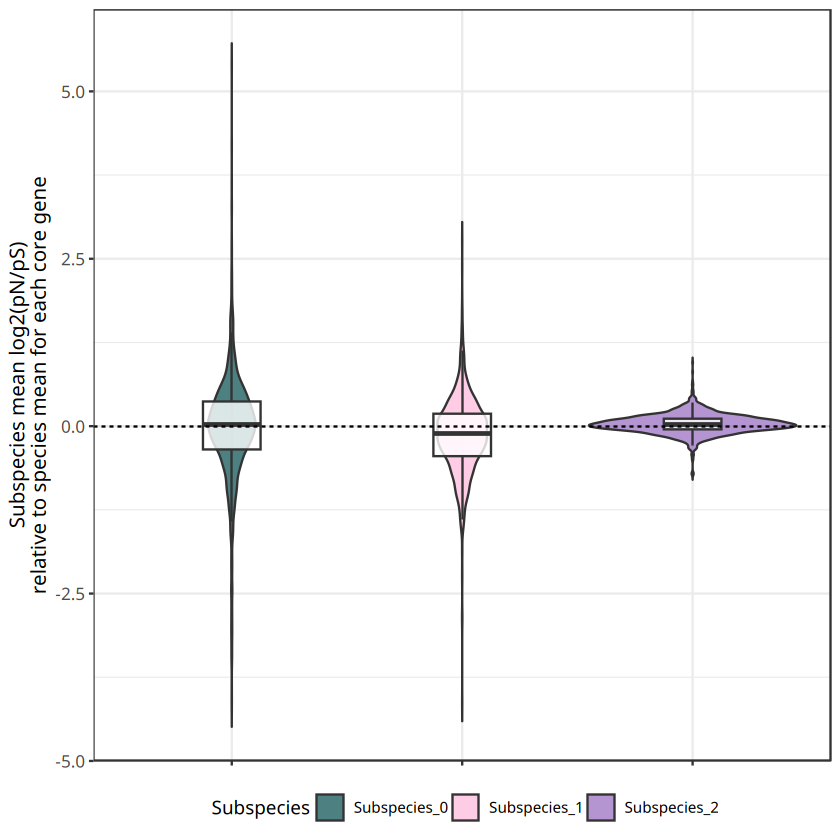

In [9]:
### Extract species core gene pNpS values, normalise by species mean and visualise
sp_core_genes_mean_log_pnps <- sp_genes_pnps_filt_w_cat %>%
  filter(., Category == "Universal") %>%
  mutate(log_pNpS = if_else(pNpS > 0, log2(pNpS), NA_real_)) %>% 
  group_by(Gene_catalog_rep) %>%
  summarise(
    spec_mean_log_pNpS = mean(log_pNpS, na.rm = TRUE),
    .groups = "drop"
  )

sp_core_genes_subsp_mean_pnps <- sp_genes_pnps_filt_w_cat %>%
  filter(., Category == "Universal") %>%
  mutate(log_pNpS = if_else(pNpS > 0, log2(pNpS), NA_real_)) %>% 
  group_by(Gene_catalog_rep, Subspecies) %>%
  summarise(
    mean_log_pNpS = mean(log_pNpS, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  left_join(sp_core_genes_mean_log_pnps, by = "Gene_catalog_rep") %>%
  mutate(
    log2_norm_pNpS = mean_log_pNpS - spec_mean_log_pNpS
  )

sp_core_genes_sample_pnps_violin <- ggplot(
  sp_core_genes_subsp_mean_pnps,
  aes(x = Subspecies, y = log2_norm_pNpS)
) +
  geom_violin(aes(fill = Subspecies), alpha = 0.7, trim = FALSE) +
  geom_boxplot(width = 0.25, outlier.shape = NA, alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = subsp_colours) +
  labs(
    y = "Subspecies mean log2(pN/pS)\nrelative to species mean for each core gene"
  ) +
  theme_bw() +
  theme(
    legend.position = "bottom",
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_blank(),
    axis.text.x = element_blank()
  )

sp_core_genes_sample_pnps_violin

ggsave(paste0(output_dir,species_id,"-sp_core_gene_pop_mean_pnps_violin.pdf"), plot = sp_core_genes_sample_pnps_violin, device = "pdf", height=6, width=5, units = "in")
ggsave(paste0(output_dir,species_id,"-sp_core_gene_pop_mean_pnps_violin.png"), plot = sp_core_genes_sample_pnps_violin, device = "png", height=6, width=5, units = "in")

## Assess variations in pNpS values of PFAM families

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


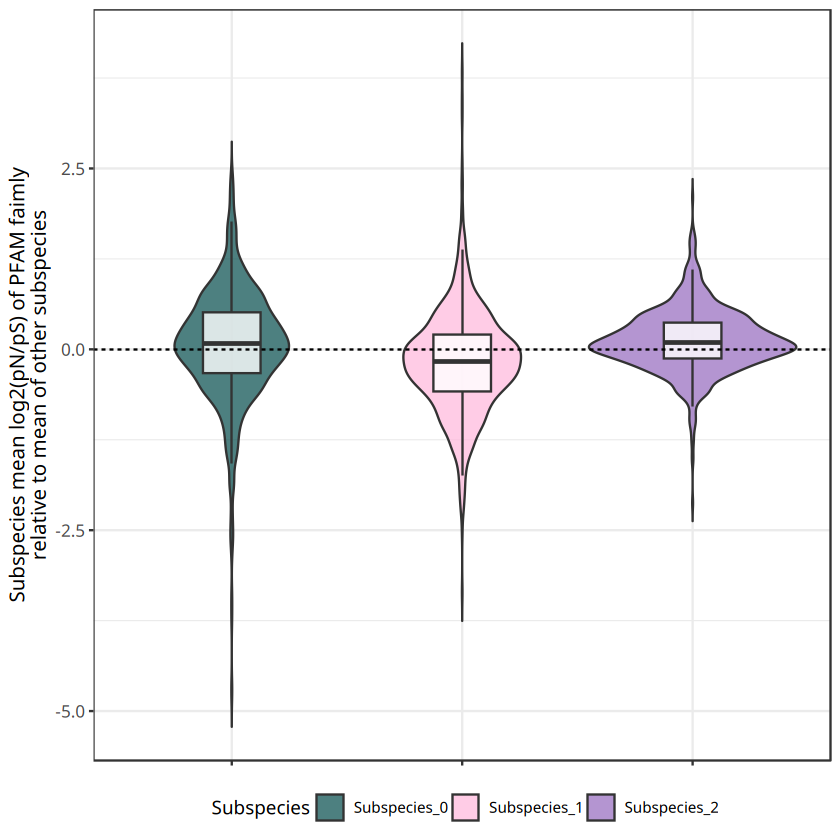

In [10]:
### Extract species core PFAM pNpS values, normalise by species mean and visualise
sp_core_pfam_subsp_norm_pnps = sp_genes_pnps_filt_w_cat %>%
  filter(., Category == "Universal" & PFAM_accession != "-") %>%
  mutate(log_pNpS = if_else(pNpS > 0, log2(pNpS), NA_real_)) %>% 
  group_by(PFAM_accession, Subspecies) %>%
  summarise(
    mean_pNpS = mean(pNpS, na.rm = TRUE),
    mean_log_pNpS = mean(log_pNpS, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(PFAM_accession) %>%
  mutate(
    loo_mean_log_pNpS = purrr::map_dbl(Subspecies, function(pop) {
      mean(mean_log_pNpS[Subspecies != pop], na.rm = TRUE)
    }),
    log_norm_pNpS = mean_log_pNpS - loo_mean_log_pNpS
  ) %>%
  ungroup()

sp_core_pfam_sample_pnps_violin <- ggplot(
  sp_core_pfam_subsp_norm_pnps,
  aes(x = Subspecies, y = log_norm_pNpS)
) +
  geom_violin(aes(fill = Subspecies), alpha = 0.7, trim = FALSE) +
  geom_boxplot(width = 0.25, outlier.shape = NA, alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = subsp_colours) +
  labs(
    y = "Subspecies mean log2(pN/pS) of PFAM faimly\nrelative to mean of other subspecies"
  ) +
  theme_bw() +
  theme(
    legend.position = "bottom",
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_blank(),
    axis.text.x = element_blank()
  )
sp_core_pfam_sample_pnps_violin

ggsave(paste0(output_dir,species_id,"-sp_core_pfam_pop_mean_pnps_violin.pdf"), plot = sp_core_pfam_sample_pnps_violin, device = "pdf", height=6, width=5, units = "in")
ggsave(paste0(output_dir,species_id,"-sp_core_pfam_pop_mean_pnps_violin.png"), plot = sp_core_pfam_sample_pnps_violin, device = "png", height=6, width=5, units = "in")

In [ ]:
#####
# Identify those PFAM families exhibiting signals of diversifying selection (pNpS >1)
#####

divers_pfam = sp_core_pfam_subsp_norm_pnps %>%
    filter(., mean_pNpS > 1) %>%
    select(PFAM_accession) %>%
    distinct() %>%
    pull(PFAM_accession)

sp_core_pfam_subsp_diversifying_pnps = sp_core_pfam_subsp_norm_pnps %>%
    filter(., PFAM_accession %in% divers_pfam)

### Export table
fwrite(sp_core_pfam_subsp_diversifying_pnps, paste0(output_tables,species_id,"-pfam_subsp_diversifying_pnps.tsv"), sep = "\t")

In [ ]:
#####
# Identify PFAM families exhibiting differential selective pressure across subspecies,
# based on a significant fold-change of pNpS values across samples 
#####

### FUNCTION to perform permutation test for significant fold change
compute_fc_permtest <- function(input_dt, group_col, n_perm = 500, seed = 1) {
  set.seed(seed)
  input_dt[, {
    pop_int <- as.integer(factor(Subspecies))
    pnps    <- pNpS
    n       <- length(pnps)
    n_pops  <- length(unique(pop_int))

    if (n < 2 || n_pops < 2) {
      list(obs_fc = NA_real_, p_perm = NA_real_, n_samples = n, n_pops = n_pops)
    } else {
      obs_n   <- rowsum(rep(1, n), pop_int)
      obs_sum <- rowsum(pnps, pop_int)
      obs_means <- obs_sum / obs_n
      obs_fc <- max(obs_means) / min(obs_means)

      perm_mat <- replicate(n_perm, pop_int[sample.int(n)])
      perm_fc <- apply(perm_mat, 2, function(p) {
        s <- rowsum(pnps, p)
        m <- s / obs_n
        max(m) / min(m)
      })
      p_perm <- (1 + sum(perm_fc >= obs_fc)) / (n_perm + 1)

      list(obs_fc = obs_fc, p_perm = p_perm, n_samples = n, n_pops = n_pops)
    }
  }, by = group_col]
}

# Filter to only consider core PFAM families at the species level and with valid pNpS values
pfam_fc_input <- sp_genes_pnps_filt_w_cat %>%
  filter(Category == "Universal", PFAM_accession != "-", !is.na(pNpS)) %>%
  select(PFAM_accession, Subspecies, Sample, pNpS) %>%
  as.data.table()

# Apply the permutation test to identify PFAM families with significant fold change across subspecies
pfam_fc_results <- compute_fc_permtest(pfam_fc_input, group_col = "PFAM_accession", n_perm = 500, seed = 1)
pfam_fc_results[, p_adj := p.adjust(p_perm, method = "BH")]

# Filter to retain only those with an adjusted p-value <0.05 from permutation test and reformat table
sp_core_pfam_subsp_signif_diff = sp_core_pfam_subsp_norm_pnps %>%
  mutate(Direction = case_when(
    log_norm_pNpS > 0 ~ "Higher_than_species_mean",
    log_norm_pNpS < 0 ~ "Lower_than_species_mean",
    TRUE ~ "No_change"
  )) %>%
  left_join(
    as_tibble(pfam_fc_results) %>% select(PFAM_accession, obs_fc, p_perm, p_adj),
    by = "PFAM_accession"
  ) %>%
  mutate(significant_fold_shift = !is.na(p_adj) & p_adj < 0.05) %>%
  filter(significant_fold_shift)

### Export table
fwrite(sp_core_pfam_subsp_signif_diff, paste0(output_tables,species_id,"-pfam_subsp_signif_change_pnps.tsv"), sep = "\t")


## Assess variations in pNpS values of KEGG orthologs

Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


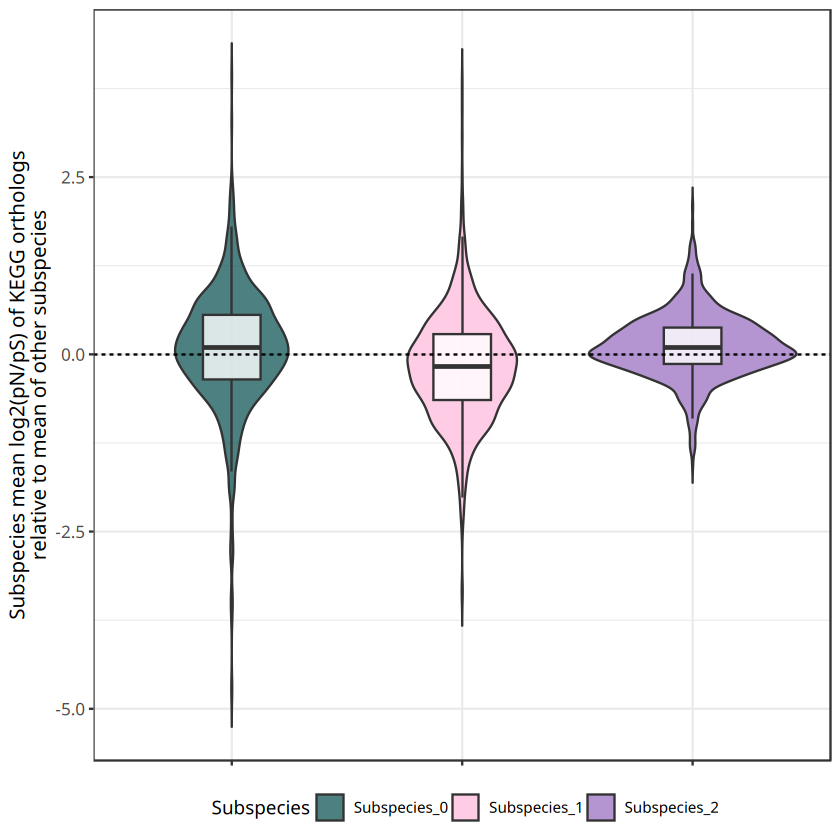

In [12]:
### Extract species core KEGG KO pNpS values, normalise by species mean and visualise
sp_core_kegg_subsp_norm_pnps = sp_genes_pnps_filt_w_cat %>%
  filter(., Category == "Universal" & KEGG_ko != "-") %>%
  mutate(log_pNpS = if_else(pNpS > 0, log2(pNpS), NA_real_)) %>% 
  group_by(KEGG_ko, Subspecies) %>%
  summarise(
    mean_pNpS = mean(pNpS, na.rm = TRUE),
    mean_log_pNpS = mean(log_pNpS, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(KEGG_ko) %>%
  mutate(
    loo_mean_log_pNpS = purrr::map_dbl(Subspecies, function(pop) {
      mean(mean_log_pNpS[Subspecies != pop], na.rm = TRUE)
    }),
    log_norm_pNpS = mean_log_pNpS - loo_mean_log_pNpS
  ) %>%
  ungroup()

sp_core_kegg_sample_pnps_violin <- ggplot(
  sp_core_kegg_subsp_norm_pnps,
  aes(x = Subspecies, y = log_norm_pNpS)
) +
  geom_violin(aes(fill = Subspecies), alpha = 0.7, trim = FALSE) +
  geom_boxplot(width = 0.25, outlier.shape = NA, alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = subsp_colours) +
  labs(
    y = "Subspecies mean log2(pN/pS) of KEGG orthologs\nrelative to mean of other subspecies"
  ) +
  theme_bw() +
  theme(
    legend.position = "bottom",
    axis.text.y = element_text(size = 10),
    axis.title.y = element_text(size = 12),
    axis.title.x = element_blank(),
    axis.text.x = element_blank()
  )
sp_core_kegg_sample_pnps_violin

ggsave(paste0(output_dir,species_id,"-sp_core_kegg_subsp_mean_pnps_violin.pdf"), plot = sp_core_kegg_sample_pnps_violin, device = "pdf", height=6, width=5, units = "in")
ggsave(paste0(output_dir,species_id,"-sp_core_kegg_subsp_mean_pnps_violin.png"), plot = sp_core_kegg_sample_pnps_violin, device = "png", height=6, width=5, units = "in")

In [ ]:
#####
# Identify those KEGG orthologs exhibiting signals of diversifying selection (pNpS >1)
#####

divers_kegg = sp_core_kegg_subsp_norm_pnps %>%
    filter(., mean_pNpS > 1) %>%
    select(KEGG_ko) %>%
    distinct() %>%
    pull(KEGG_ko)

sp_core_kegg_subsp_diversifying_pnps = sp_core_kegg_subsp_norm_pnps %>%
    filter(., KEGG_ko %in% divers_kegg)

fwrite(sp_core_kegg_subsp_diversifying_pnps, paste0(output_dir,species_id,"-kegg_subsp_diversifying_pnps.tsv"), sep = "\t")

In [ ]:
#####
# Identify KEGG orthologs exhibiting differential selective pressure across subspecies,
# based on a significant fold-change of pNpS values across samples 
#####

# Filter to only consider core KEGG orthologs at the species level and with valid pNpS values
kegg_fc_input <- sp_genes_pnps_filt_w_cat %>%
  filter(Category == "Universal", KEGG_ko != "-", !is.na(pNpS)) %>%
  select(KEGG_ko, Subspecies, Sample, pNpS) %>%
  as.data.table()

# Apply the permutation test (function specified above for PFAM families) to identify KEGG orthologs with significant fold change across subspecies
kegg_fc_results <- compute_fc_permtest(kegg_fc_input, group_col = "KEGG_ko", n_perm = 500, seed = 1)
kegg_fc_results[, p_adj := p.adjust(p_perm, method = "BH")]

# Filter to retain only those with an adjusted p-value <0.05 from permutation test and reformat table
sp_core_kegg_subsp_signif_diff_pnps = sp_core_kegg_subsp_norm_pnps %>%
  left_join(
    as_tibble(kegg_fc_results) %>% select(KEGG_ko, obs_fc, p_perm, p_adj),
    by = "KEGG_ko"
  ) %>%
  mutate(significant_fold_shift = !is.na(p_adj) & p_adj < 0.05) %>%
  filter(significant_fold_shift)

fwrite(sp_core_kegg_subsp_signif_diff_pnps, paste0(output_dir,species_id,"-kegg_subsp_signif_change_pnps.tsv"), sep = "\t")


In [ ]:
#####
# Retrieve descriptions and annotations for KEGG ko's
#####

kegg_signif_df = sp_core_kegg_subsp_signif_diff_pnps %>%
    select(KEGG_ko)
kegg_divers_df = sp_core_kegg_subsp_diversifying_pnps %>%
    select(KEGG_ko)

kegg_kos = unique(rbind(kegg_signif_df,kegg_divers_df)$KEGG_ko)


### FUNCTIONS to extract pathway, metabolism and module information for KEGG ko's using KEGGREST
get_ko_entry_safe <- function(ko) {
  Sys.sleep(0.2)
  
  tryCatch(
    {
      entry <- KEGGREST::keggGet(paste0("ko:", ko))[[1]]
      entry
    },
    error = function(e) {
      message("Failed for ", ko, ": ", e$message)
      NULL
    }
  )
}

ko_details_raw <- purrr::set_names(kegg_kos) %>%
  purrr::map(get_ko_entry_safe)

# Remove failed entries
ko_details_raw <- purrr::compact(ko_details_raw)

ko_details <- purrr::imap_dfr(ko_details_raw, function(x, ko) {
  
  tibble(
    KEGG_ko = ko,
    KEGG_entry = if (!is.null(x$ENTRY)) paste(x$ENTRY, collapse = "; ") else NA_character_,
    Gene_name = if (!is.null(x$SYMBOL)) paste(x$SYMBOL, collapse = "; ") else NA_character_,
    KEGG_name = if (!is.null(x$NAME)) paste(x$NAME, collapse = "; ") else NA_character_,
    KEGG_definition = if (!is.null(x$DEFINITION)) paste(x$DEFINITION, collapse = "; ") else NA_character_
  )
}) %>%
  distinct()

ko_details_combined <- tibble(KEGG_ko = kegg_kos) %>%
  left_join(ko_details, by = "KEGG_ko")

### Extract pathway and module annotation
ko_pathway_module_details <- purrr::imap_dfr(ko_details_raw, function(x, ko) {
  
  pathways <- x$PATHWAY
  modules <- x$MODULE
  
  pathway_df <- if (!is.null(pathways)) {
    tibble(
      KEGG_ko = ko,
      annotation_type = "Pathway",
      annotation_id = names(pathways),
      annotation_description = unname(pathways)
    )
  } else {
    tibble(
      KEGG_ko = ko,
      annotation_type = "Pathway",
      annotation_id = NA_character_,
      annotation_description = NA_character_
    )
  }
  
  module_df <- if (!is.null(modules)) {
    tibble(
      KEGG_ko = ko,
      annotation_type = "Module",
      annotation_id = names(modules),
      annotation_description = unname(modules)
    )
  } else {
    tibble(
      KEGG_ko = ko,
      annotation_type = "Module",
      annotation_id = NA_character_,
      annotation_description = NA_character_
    )
  }
  
  bind_rows(pathway_df, module_df)
}) %>%
  filter(!is.na(annotation_id)) %>%
  distinct()

### Build annotation table
ko_annotation_compact <- ko_details_combined %>%
  left_join(
    ko_pathway_module_details %>%
      filter(annotation_type == "Pathway") %>%
      group_by(KEGG_ko) %>%
      summarise(
        Pathway_IDs = paste(sort(unique(annotation_id)), collapse = "; "),
        Pathway_descriptions = paste(sort(unique(annotation_description)), collapse = "; "),
        .groups = "drop"
      ),
    by = "KEGG_ko"
  ) %>%
  left_join(
    ko_pathway_module_details %>%
      filter(annotation_type == "Module") %>%
      group_by(KEGG_ko) %>%
      summarise(
        Module_IDs = paste(sort(unique(annotation_id)), collapse = "; "),
        Module_descriptions = paste(sort(unique(annotation_description)), collapse = "; "),
        .groups = "drop"
      ),
    by = "KEGG_ko"
  )

### Combine tables with KEGG kos under differential selective pressure with annotations
sp_core_kegg_subsp_signif_diff_pnps_w_desc = sp_core_kegg_subsp_signif_diff_pnps %>%
    left_join(ko_annotation_compact, by="KEGG_ko")
  
sp_core_kegg_subsp_diversifying_pnps_w_desc = sp_core_kegg_subsp_diversifying_pnps %>%
    left_join(ko_annotation_compact, by="KEGG_ko")

fwrite(sp_core_kegg_subsp_signif_diff_pnps_w_desc, paste0(output_dir,species_id,"-kegg_subsp_signif_change_pnps.tsv"), sep = "\t")
fwrite(sp_core_kegg_subsp_diversifying_pnps_w_desc, paste0(output_dir,species_id,"-kegg_subsp_diversifying_pnps.tsv"), sep = "\t")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <a4>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≤0.001' in 'mbcsToSbcs': dot substituted for <a4>”
Warning message in grid.Call.graphics(C_text, as.

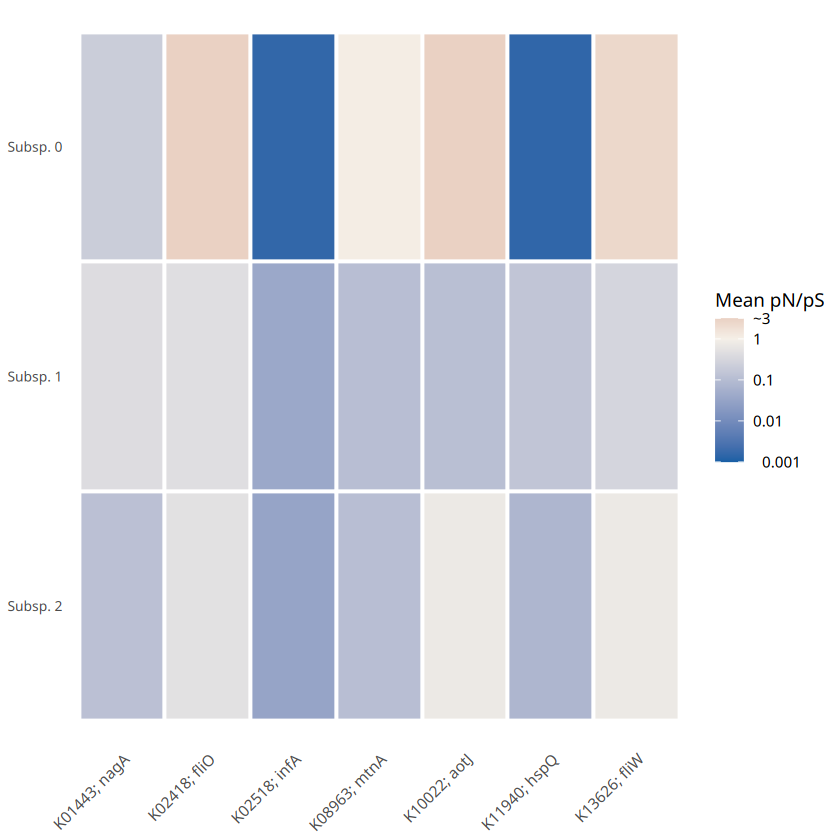

In [ ]:
#####
# Visualise variation in pNpS of selected KO's in heatmap
#####

kos_to_plot <- c("K10022","K08963","K02418","K13626","K11940","K02518","K01443")

sp_core_kegg_subsp_signif_diff_pnps_w_desc_min = sp_core_kegg_subsp_signif_diff_pnps_w_desc %>%
  select(KEGG_ko,Subspecies,mean_pNpS,Gene_name)

sp_core_kegg_subsp_diversifying_pnps_w_desc_min = sp_core_kegg_subsp_diversifying_pnps_w_desc %>%
  select(KEGG_ko,Subspecies,mean_pNpS,Gene_name)

sp_core_kegg_pnps_plot_df = rbind(
    sp_core_kegg_subsp_signif_diff_pnps_w_desc_min,
    sp_core_kegg_subsp_diversifying_pnps_w_desc_min
  ) %>%
  distinct() %>%
  filter(., KEGG_ko %in% kos_to_plot) %>%
  mutate(Gene_name_plot = gsub(",.*","",Gene_name)) %>%
  mutate(KO_label = paste0(KEGG_ko,"; ",Gene_name_plot)) %>%
  mutate(Subspecies = case_when(
    Subspecies == "Subspecies_0" ~ "Subsp. 0",
    Subspecies == "Subspecies_1" ~ "Subsp. 1",
    Subspecies == "Subspecies_2" ~ "Subsp. 2"
  )) %>%
  mutate(KEGG_ko = factor(KEGG_ko, levels=unique(kos_to_plot)))

sp_core_kegg_pnps_heatmap <- ggplot(
  sp_core_kegg_pnps_plot_df %>%
    mutate(
      log_pNpS = log10(mean_pNpS),
      log_pNpS = if_else(is.infinite(log_pNpS), NA_real_, log_pNpS)
    ),
  aes(x = KO_label, y = Subspecies, fill = log_pNpS)
) +
  geom_tile(colour = "white", linewidth = 0.8) +
  scale_fill_gradient2(
    low      = "#185FA5",
    mid      = "#f5f0e8",
    high     = "#993C1D",
    midpoint = 0,
    limits   = c(-3, 0.5),
    breaks   = c(-3, -2, -1, 0, 0.5),
    labels   = c("≤0.001", "0.01", "0.1", "1", "~3"),
    name     = "Mean pN/pS",
    oob      = scales::squish,   # values outside limits clamp to nearest end
    na.value = "#0d3d6b"         # zeros map to darkest blue -- real signal
  ) +
  labs(x = NULL, y = NULL) +
  scale_y_discrete(limits=rev) + 
  theme_bw() +
  theme(
    axis.text.y  = element_text(size = 8),
    axis.text.x  = element_text(angle = 45, hjust = 1, size = 9),
    legend.position = "right",
    panel.grid   = element_blank(),
    panel.border = element_blank(),
    axis.ticks   = element_blank()
  )
  
sp_core_kegg_pnps_heatmap
ggsave(paste0(output_dir,species_id,"-sp_core_ko_subsp_pnps_outlier_heatmap.pdf"), plot = sp_core_kegg_pnps_heatmap, device = "pdf", height=4, width=7, units = "in")
ggsave(paste0(output_dir,species_id,"-sp_core_ko_subsp_pnps_outlier_heatmap.png"), plot = sp_core_kegg_pnps_heatmap, device = "png", height=4, width=7, units = "in")

# Case study figure

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 127 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing non-finite outside the scal

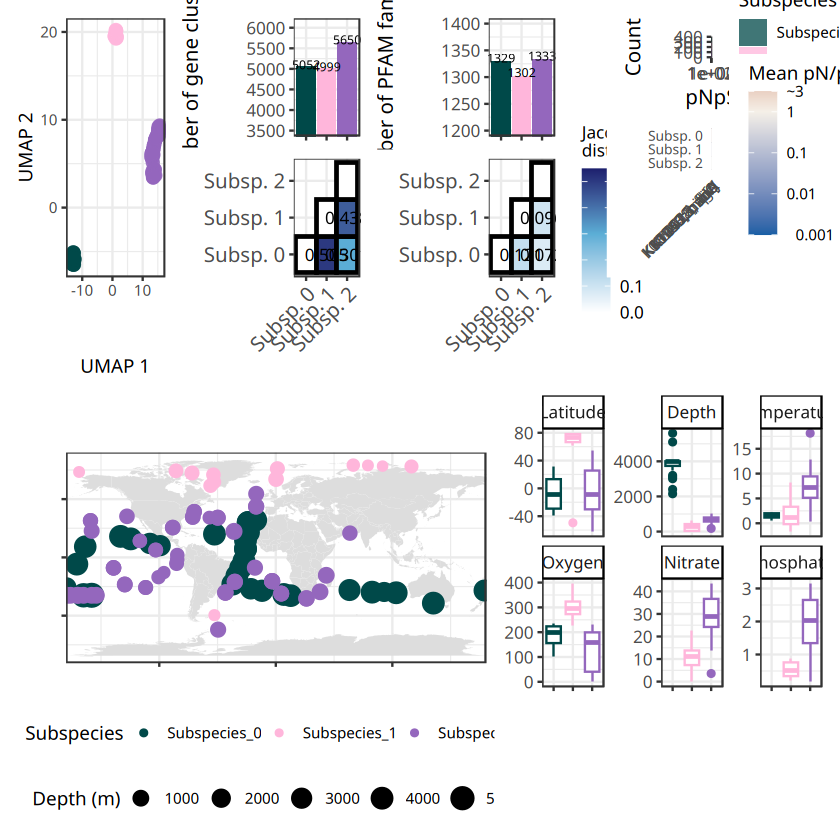

In [39]:
#####
# Create case study figure
#####

### UMAP + gene cluster and pfam composition
subsp_sample_snv_dist_umap_mod = subsp_sample_snv_dist_umap + 
  theme(legend.position = "none")

subspecies_gene_cluster_jaccard_dist_heatmap_mod = subspecies_gene_cluster_jaccard_dist_heatmap + 
  theme(legend.position = "none")

subspecies_pfam_jaccard_dist_heatmap_mod = subspecies_pfam_jaccard_dist_heatmap + 
  theme(legend.position = "right")

gene_comp_p1 <- (subspecies_gene_cluster_counts_barplot / subspecies_gene_cluster_jaccard_dist_heatmap_mod)
gene_comp_p2 <- (subspecies_pfam_family_counts_barplot / subspecies_pfam_jaccard_dist_heatmap_mod)

pnps_histo_and_heatmap <- sp_core_gene_pop_mean_pnps_histogram/sp_core_kegg_pnps_heatmap+plot_layout(heights = c(0.5,1))

top_row <- subsp_sample_snv_dist_umap_mod + gene_comp_p1 + gene_comp_p2 + wrap_elements(pnps_histo_and_heatmap) +
  plot_layout(widths=c(0.75,0.5,0.5,1.1))

### Map and environmental parameter boxplots
# species_pop_map_mod = species_pop_map + theme(legend.position = "bottom")
sp_phased_samples_env_boxplot_mod = sp_phased_samples_env_boxplot + theme(legend.position = "none")

bottom_row <- species_map + sp_phased_samples_env_boxplot_mod + plot_layout(widths=c(1.5,1))

### Combine all
sp_case_study_figure = top_row/bottom_row + plot_layout(height=c(1,1))
sp_case_study_figure
ggsave(paste0(output_dir,species_id,"-case_study_figure.pdf"), plot = sp_case_study_figure, device = "pdf", height=10, width=14, units = "in")
ggsave(paste0(output_dir,species_id,"-case_study_figure.png"), plot = sp_case_study_figure, device = "png", height=10, width=14, units = "in")
